# Bending Algebra Explained
The linear algebra behind the bending modes is tricky, and how it relates forces on the mirror (by actuators) to the change in shape of the mirror (called Influence functions).

## Setup of environment/coordinates

In [27]:
from pathlib import Path

import numpy as np
import psd_utils
from rfcml_bending import Bending
from rfcml_bending.force_matrix import ForceSpace
from matplotlib import pyplot as plt
from scipy.interpolate import griddata

Load a forceMatrix file, which is provided by Steve West.<br>
These are convenience functions for him that are used elsewhere, but I found it hard to understand the relationship between code and theory, so I started from scratch.


In [6]:
# file_path = Path("/Users/pingraham/repos/uasal/psd_utils/tests/data/stp_tel_166_forcespace_mkII.mat")
file_path = Path("/Users/patrickingraham/repos/rfcml_bending/tests/data/six_five_100_forcespace_mkIII.mat")
force_space = ForceSpace(file_path)

The arrays in the forcespace are based around a point cloud of nodes. These are not convenient for plotting, so we'll make a rectilinear coordinate space that we can go to-and-from easily.

### Create a rectilinear coordinate grid, mostly for plotting ease.
For this exercise we'll keep the sampling very similar to minimize interpolation issues

In [9]:
psd_tools = psd_utils.PSDUtils()
xrange = np.max(force_space.data["x_nodes"]) - np.min(force_space.data["x_nodes"])  # mm

n_nodes = len(force_space.data["x_nodes"])
# area of a square the encompasses a circle of radius r is 2r*2r=4r^2
# so a square will have 4r^2 / pi r^2 more samples = 1.273
# so a side has to be ~sqrt(1.273) longer
side = int(np.sqrt(n_nodes) * np.sqrt(1.273))
dims = (side * 1, side * 1)
dx = xrange / dims[0]
coords = psd_tools.coord_arrays(dims, dx=dx, offset_x=0.0, offset_y=0.0)

## Influence Functions

In this map, the number of FEA nodes is Y, and the number of actuators is N
The A matrix is a YxN matrix where the columns are the actuator forces and the rows are surface shape. The deformation (in nm) is obtained for the force of 1 lb of force (lbF). So the rows (Y) are in nm, and the columns (N) are in lbF. 

The equation that relates the A matrix to a surface is: <br>

$A f = z$, <br>

where $f$ is a $N\times1$ matrix in lbF, and $z$ is then $Y\times1$ matrix in nm.

In [10]:
print(f"shape (rows,columns) is: {force_space.data['A'].shape}")
Y = force_space.data["A"].shape[0]
N = force_space.data["A"].shape[1]
print(f"{Y=}, {N=}")

shape (rows,columns) is: (17058, 100)
Y=17058, N=100


### Plot an example influence function

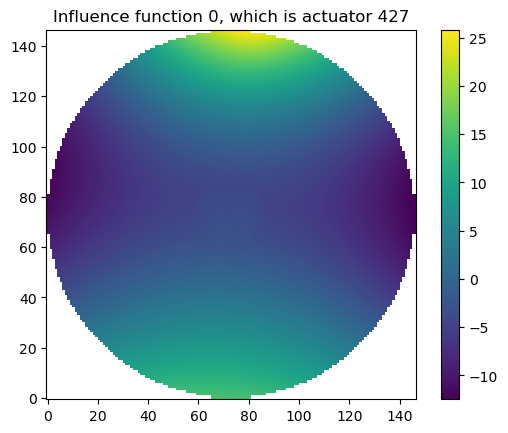

In [21]:
inf_fxn = 0
influence_fea = force_space.data["A"][:, inf_fxn]  # A is YbyN, so want Y (row)

influence_grid = force_space.fea_to_grid(influence_fea, coords=coords, method="linear")
if True:
    plt.imshow(influence_grid, origin="lower")
    plt.colorbar()
    plt.title(f"Influence function {inf_fxn}, which is actuator {force_space.data['FEA_act_ids'][inf_fxn]}")

## Singular Value Decomposition
What we normally need to do is go from a measured surface z to determine the correction forces required (f). This requires multiplying both sides by the inverse of A (on the left side).<br>
So,<br>
 $A f = z$ <br>
 Becomes, <br>
 $f={A^{-1}}z$ <br>
 The problem is that A is not easily invertible. So we can use SVD to represent the matrix A, then use a pseudo inverse to represent $A^{-1}$.<br>

 SVD decomposes a matrix into a product of 3 individual matrices, which each have their own properties. Because A is all real values we can represent it as:<br>
 $A= U \Sigma V^T$ <br>

 Note that the pseudo-inverse is given by:
 ${\displaystyle \mathbf {A} ^{-1}=\mathbf {V} {\boldsymbol {\Sigma }}^{-1}\mathbf {U} ^{T},}$ where $\Sigma^{-1}$ is diagonal with each value being the recipricals of the values in $\Sigma$.
 
$U$ contains the ortho-normal basis of displacements that can occur by driving combinations of actuators. It will be a NxN dimensional matrix, where each column is a displacement vector, and each row is a force of each actuator. The U-matrix has columns which have units that are the same as the rows from A.
Remember for matrix $A$, the Y rows (of length N) are in nm, and the N columns (of length Y) are in lbF. So the columns in the U-matrix are in nm.

$\Sigma$ is diagonal matrix (so square, but can be made rectangular with zeros etc) with singular values on the diagonal. The singular values are real, non-negative numbers, and they have no specific physical units. They represent the "strengths" or "magnitudes" of the singular values, we refer to them as *weights*.

$V^T$ is unitary matrix with orthonormal columns. The columns of V are the right singular vectors of the original matrix. The units of the columns of V are the same as the units of the columns of the original matrix, which are lbF.

So in summary:
- $U$ is displacements, where each column is a unique shape called a *bending mode*
- $\Sigma$ is a weighting factor that relates force to displacement. Meaning some bending modes take less or more force than others.
- $V^T$ is orthonormal set of forces for each bending mode.

Note that there is a slide by Buddy (in the docs) that says V is NxN, which is a mistake.


In [12]:
# this will take ~20s
U_full, sigma_full, V_T_full = np.linalg.svd(force_space.data["A"], full_matrices=True)
U, sigma, V_T = np.linalg.svd(force_space.data["A"], full_matrices=False)

Examine the output shapes as there is some numerical trickery here that is confusing.<br>
To save memory and compute, many zeros are omitted from the arrays, which results in them changing size and shape.<br>
Also, the output from SVD has already transposed the $V$ matrix, outputting $V^T$, which is why I named the variable as such.

In [13]:
print(f"{force_space.data['A'].shape=}")
print(f"{U_full.shape=}, {U.shape=}")
print(f"{sigma_full.shape=}, {sigma.shape=}")
print(f"{V_T_full.shape=}, {V_T.shape=}")

force_space.data['A'].shape=(17058, 100)
U_full.shape=(17058, 17058), U.shape=(17058, 100)
sigma_full.shape=(100,), sigma.shape=(100,)
V_T_full.shape=(100, 100), V_T.shape=(100, 100)


The changing of their sizes means you can't just multiply them back together to get $A$, as it will cause dimensionality issues.<br>
1. You need to create a 2d diagonlized matrix for sigma
2. The full matrices are squares, U is NxN, V_T is YbyY.  I've never figured out why nor how to properly fix this.

Below is a check to see that we recovered A

In [14]:
A = force_space.data["A"]
X_a = np.matmul(np.matmul(U, np.diag(sigma)), V_T)  # same syntax as: X_a = U @ diag(sigma) @ V_T
# print(np.std(A), np.std(X_a), np.std(A - X_a))
np.allclose(A, X_a)  # checks that both are within numerical precision

True

In [15]:
# The following fails because sigma is the wrong shape(s), but I'm unsure as to why.
# X_a = np.matmul(np.matmul(U_full, np.diag(sigma_full)), V_T_full)


### Plot an example of a bending mode
These are columns of U, except the columns of U correspond to surface at each actuator. The columns of V are the forces, but the scaling won't be correct. The scaling is in the sigma array, but let's first look at how we can use our formula and the influence functions to get the shape.<br>

$A f = z$, so how do we get the forces

 Remember that the pseudo-inverse is given by:
 ${\displaystyle \mathbf {A} ^{-1}=\mathbf {V} {\boldsymbol {\Sigma }}^{-1}\mathbf {U} ^{T},}$ where $\Sigma^{-1}$ is diagonal with each value being the recipricals of the values in $\Sigma$. So:

 f = $\mathbf {V} {\boldsymbol {\Sigma }}^{-1}\mathbf {U} ^{T} z $,

 So we can figure out the forces required to create a bending mode.


In [22]:
sigma_inv = np.diag(1 / sigma)
A_inv = V_T.T @ sigma_inv @ U.T
# Check to make sure this is correct
test = A_inv @ A
np.allclose(np.identity(N), test)

True

Lets pick a bending mode (zero) and walk through the exercise. We'll choose what Steve did in his example (which was BM1 in matlab, but Matlab is 1-indexed and Python is 0-indexed)

In [23]:
n_bending_mode = 0  # bending mode to plot (note matlab is 1 indexed, and python is 2 indexed)
f_of_bm0 = A_inv @ U[:, n_bending_mode]
f_of_bm0.shape

(100,)

So now multiply the influence functions by the forces to get the surface of bending mode 0, and resample to plot.

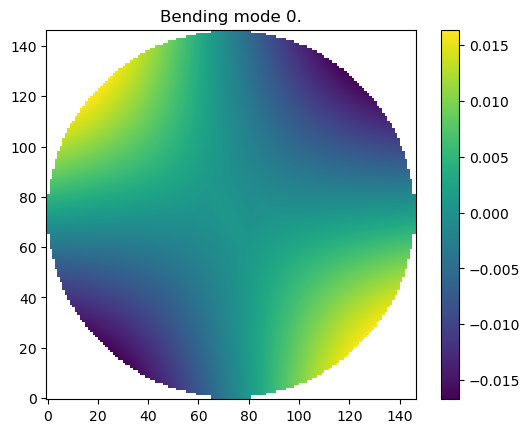

In [24]:
bm0_surface = A @ f_of_bm0

mirror_shape_grid = force_space.fea_to_grid(bm0_surface, coords=coords, method="linear")
if True:
    plt.imshow(mirror_shape_grid, origin="lower")
    plt.colorbar()
    plt.title(f"Bending mode {n_bending_mode}.")

Now, this result must also just be the column of U, since we used that to calculate the forces, so lets verify that. <br>

In [25]:
np.allclose(bm0_surface, U[:, n_bending_mode])

True

Now lets plot the force map, which is the force applied from each actuator. <br>
Remember that we calculated the forces required based on the desired bending mode shape, but that forces are also contained in the V matrix. Let's start by looking at that matrix.

Note the following is low resolution and then extrapolated, so it'll have a slightly odd shape. Also, this matrix is also what is created by Steve's example document.

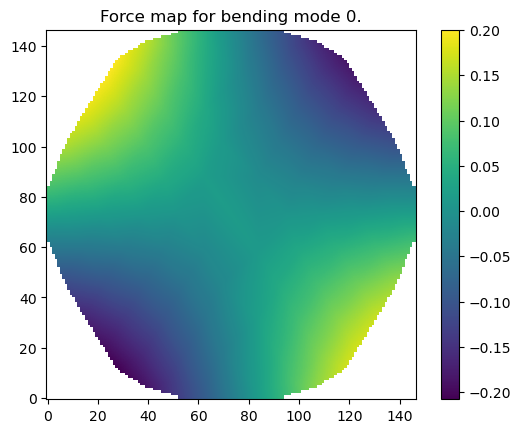

In [28]:
if True:
    # map = f_of_bm0  # Uncomment to make the plot of our calculated forces
    map = V_T[n_bending_mode, :]  # reproduces Steves plot
    xrange = np.max(force_space.data["x_act"]) - np.min(force_space.data["y_act"])
    dx = xrange / 150
    coords_acts = psd_tools.coord_arrays(dims, dx=dx, offset_x=0.0, offset_y=0.0)
    map = griddata(
        (force_space.data["x_act"], force_space.data["y_act"]), map, (coords_acts.x_grid, coords_acts.y_grid)
    )
    plt.imshow(map, origin="lower")
    plt.colorbar()
    plt.title(f"Force map for bending mode {n_bending_mode}.")

So let's compare that to our calculate values. Spoiler alert, the shape is identical, but there is a uniform scaling factor between the two matrices.<br>
You can display the calculated force map by uncommenting the line above.

In [29]:
ratio_of_maps = f_of_bm0 / V_T[n_bending_mode, :]
print(f"{np.median(ratio_of_maps)=}, which is the scaling factor.")
print(f"{np.std(ratio_of_maps)=}, shows it's all the same value")

np.median(ratio_of_maps)=0.0001952004174103, which is the scaling factor.
np.std(ratio_of_maps)=5.505714156981612e-12, shows it's all the same value


Unsurprisingly, this is the value in the first element of the $\Sigma^-1$ array.

In [30]:
np.allclose(np.median(ratio_of_maps), sigma_inv[0, 0])

True

This means that the forces associated with each bending mode are given by: <br>
$F_{bending} = V \Sigma^{-1} $

In [31]:
F_bending = V_T.T @ sigma_inv
# Verify the same result
np.allclose(F_bending[:, 0], f_of_bm0)

True

## Force Balancing
The forces associated with each bending mode are not balanced. Let's pretend the mirror is fixed to the support structure at a single point in the center and we're in a zero gravity environment. This means that a push of an actuator would move induce a moment (torque) about the mirror pivot and apply aberration throughout the mirror that is not consistent with the influence functions. If the mirror were not attached, then essentially an actuator force would send it floating into space. This means that to apply a net force for an actuator of 1, all other actuators need to pull down to ensure a net force of 0 across the mirror, and that there is no moment (torque) being applied, which ensures the influence functions are realistic.

The forceSpace object has an array that relates actuator forces to load cases. A load case is the forces applied to all the actuators mirror to ensure a net zero force when you want to apply a force at a single actuator. The array, which has a key of "af2lc", which stands for, "actuator forces 2 load cases" is sorted by actuator number.

The load cases are derived using an FEA model (by Mario).

To demonstrate this, let's look at the force applied for pushing an actuator. We'll use the same actuator as we did at the beginning, which corresponds to influence fxn 0.<br>

We can plot (or print) the force and see that it's nearly 1 at the first actuator, and that the sum of the entire array is zero.

[ 9.58440963e-01 -3.96527120e-02 -3.85658845e-02 -3.83113082e-02
 -3.72056964e-02 -3.26438441e-02 -3.33238055e-02 -3.40660630e-02
 -3.38108298e-02 -2.73382042e-02 -2.80804616e-02 -2.88227191e-02
 -2.95649766e-02 -2.14149272e-02 -2.20948886e-02 -2.28371461e-02
 -2.35793753e-02 -2.43216327e-02 -4.48085676e-03 -1.68515448e-02
 -1.75938023e-02 -1.83360597e-02 -1.79328534e-02 -1.09896577e-02
 -1.16082292e-02 -1.23504584e-02 -1.30927159e-02 -1.65046668e-02
 -5.62262790e-03 -6.36488538e-03 -7.10714285e-03 -8.85118677e-03
  1.04290653e-03  3.62945110e-04 -3.79312361e-04 -1.12154152e-03
 -1.86379899e-03  6.34854645e-03  5.60628897e-03  4.86403150e-03
  4.12177403e-03  1.22718234e-02  1.15918620e-02  1.08496045e-02
  9.23359894e-03  1.75762267e-02  1.59610481e-02  1.29067025e-02
  2.08947340e-02  1.64399347e-02 -4.08947340e-02 -3.64399347e-02
 -3.75762267e-02 -3.59610481e-02 -3.29067025e-02 -3.22718234e-02
 -3.15918620e-02 -3.08496045e-02 -2.92335989e-02 -2.63485465e-02
 -2.56062889e-02 -2.48640

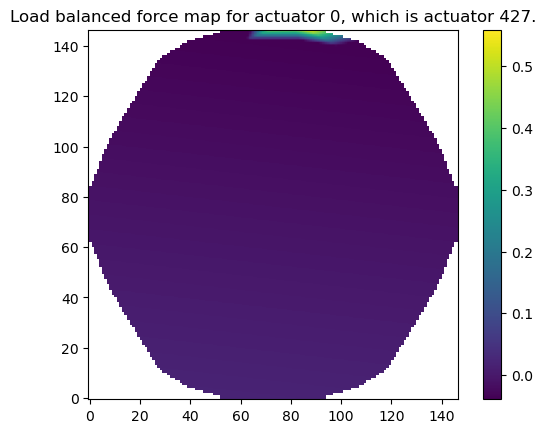

In [32]:
print(force_space.data["af2lc"][inf_fxn, :])

if True:
    map = force_space.data["af2lc"][inf_fxn, :]
    xrange = np.max(force_space.data["x_act"]) - np.min(force_space.data["y_act"])
    dx = xrange / 150
    coords_acts = psd_tools.coord_arrays(dims, dx=dx, offset_x=0.0, offset_y=0.0)
    map = griddata(
        (force_space.data["x_act"], force_space.data["y_act"]), map, (coords_acts.x_grid, coords_acts.y_grid)
    )
    plt.imshow(map, origin="lower")
    plt.colorbar()
    plt.title(
        f"Load balanced force map for actuator {inf_fxn}, which is actuator {force_space.data['FEA_act_ids'][inf_fxn]}."
    )

In [33]:
print(f"Force of actuator of interest is {force_space.data['af2lc'][inf_fxn, 0]}")
print(
    f"Sum of all forces is {np.sum(force_space.data['af2lc'][inf_fxn, :])}, which is consistent with zero (to numerical accuracy.)"
)
np.allclose(np.sum(force_space.data["af2lc"][inf_fxn, :]), 0)

Force of actuator of interest is 0.9584409634483864
Sum of all forces is 8.588012939680922e-11, which is consistent with zero (to numerical accuracy.)


True

So how do we shape the mirror and ensure we have a net zero force?

We calculate the array of forces based on the surface, but then we need to multiply each of these actuator forces by the forces to load-case matrix. Let's call this $\Delta_af2lc$

$\Delta_{af2lc} f = f_{applied}$ <br>

In the case above, we had used the forces of a single actuator as our $f$, let's do something more realistic, and look at the forces of the bending mode that we calculated and stored in the variable `f_of_bm0`.

In [34]:
f_balanced = force_space.data["af2lc"] @ f_of_bm0
f_balanced.shape

np.allclose(np.sum(f_balanced), 0)

True

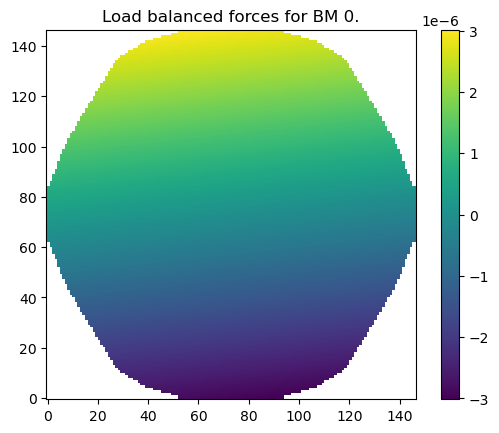

In [35]:
if True:
    map = f_of_bm0 - f_balanced
    # map = ((f_of_bm0-f_balanced)/np.abs(f_of_bm0)) * 100

    xrange = np.max(force_space.data["x_act"]) - np.min(force_space.data["y_act"])
    dx = xrange / 150
    coords_acts = psd_tools.coord_arrays(dims, dx=dx, offset_x=0.0, offset_y=0.0)
    map = griddata(
        (force_space.data["x_act"], force_space.data["y_act"]), map, (coords_acts.x_grid, coords_acts.y_grid)
    )
    plt.imshow(map, origin="lower")
    plt.colorbar()
    plt.title("Load balanced forces for BM 0.")

### Analysis of Moments and Net Force
It is important to ensure the net force and net moments are zero (or within a reasonable limit).<br>
At this time I (Patrick) don't know the acceptable limit. <br>
For the moment we'll assume it's equivalent to the net force at the outside of the mirror.

Note that the method to calculate moments is part of the Bending class which needs to be instantiated.

In [36]:
bending = Bending(file_path)

In [37]:
limit = np.sum(f_balanced) * np.max(force_space.data["x_act"])
mom_x, mom_y = bending.calc_moments(f_balanced, limit=limit)
print(f"{mom_x=}, {mom_y=}")

mom_x=3.4916514124461173e-14, mom_y=1.4393347624874764e-13


## Comparison between Steve's ForceSpace and our ForceSpace objects
Steve has developed a formalism which works for him, but the naming is not consistent with Buddy's slides that explain how bending modes work. Furthermore, the forceSpace matrix produced by Steve is not identical in units an occasionally the keys can change. Lastly, there have been forceSpaces created by others (notably Becca (Lastnam?)) that again have a different format. For this reason we've opted to build a wrapper for those and create a single format that is used in this package. <br>
Below on some notes on how the matricies relate.

Steve uses the formalism of U_n(:,i) * Un_scale is the surface for forces V_m(:,i).
So he basically scales the bending modes to match forces, what we did above was to scale the forces to match the bending modes.

sigma.shape

In [ ]:
force_space.data["W"].shape

In [ ]:
sigma.shape

In [ ]:
# So Sigma an s_Un (which we called W), is the same thing
np.allclose(force_space.data["W"], sigma)

In [ ]:
# Steve's V_m is equal to V (not V transpose!)
np.allclose(force_space.data["V"], V_T.T)

In [ ]:
# Steve's U_m is equal to U
np.allclose(force_space.data["U"], U)

Just useful snippets to compare raw forcespaces manually. 

In [38]:
import scipy

In [ ]:
forcespace_path = Path("/Users/patrickingraham/repos/psd_utils/tests/data/six_five_100_forcespace_mkIII.mat")
force_space = scipy.io.loadmat(forcespace_path)
np.max(force_space["FEA_act_xy"])

In [ ]:
forcespace_path = Path("/Users/patrickingraham/repos/psd_utils/tests/data/um_42_forcespace.mat")
force_space = scipy.io.loadmat(forcespace_path)
np.max(force_space["FEA_act_xy"])